In [4]:
from pathlib import Path
from sklearn.model_selection import train_test_split
import shutil

# Dossier contenant les classes
data_dir = Path("data/raw")

# Extensions acceptées
extensions = {".png"}

images = []
labels = []

# Chaque sous-dossier représente une classe
for classe_dir in data_dir.iterdir():
    if classe_dir.is_dir():
        for image_path in classe_dir.rglob("*"):
            if image_path.suffix.lower() in extensions:
                images.append(image_path)
                labels.append(classe_dir.name)

# Séparation 80 % entraînement / 20 % test
X_train, X_test, y_train, y_test = train_test_split(
    images,
    labels,
    test_size=0.20,
    random_state=42,
    stratify=labels
)

# Dossiers de destination
train_dir = Path("data/split/train")
test_dir = Path("data/split/test")

for image_path, label in zip(X_train, y_train):
    destination = train_dir / label
    destination.mkdir(parents=True, exist_ok=True)
    shutil.copy2(image_path, destination / image_path.name)

for image_path, label in zip(X_test, y_test):
    destination = test_dir / label
    destination.mkdir(parents=True, exist_ok=True)
    shutil.copy2(image_path, destination / image_path.name)

print(f"Images d'entraînement : {len(X_train)}")
print(f"Images de test : {len(X_test)}")


Images d'entraînement : 600
Images de test : 150


In [8]:
import numpy as np
from PIL import Image
from skimage.feature import local_binary_pattern
from sklearn.base import BaseEstimator, TransformerMixin



class LBPFeatures(BaseEstimator, TransformerMixin):

    def __init__(self, image_size=(128, 128), radius=3, n_points=24):
        self.image_size = image_size
        self.radius = radius
        self.n_points = n_points

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        features = []
        n_bins = self.n_points + 2

        for image_path in X:
            image = Image.open(image_path).convert("L")
            image = image.resize(self.image_size)

            image_array = np.array(image)

            lbp = local_binary_pattern(
                image_array,
                self.n_points,
                self.radius,
                method="uniform"
            )

            histogram, _ = np.histogram(
                lbp.ravel(),
                bins=np.arange(0, n_bins + 1),
                range=(0, n_bins)
            )

            histogram = histogram.astype("float32")
            histogram /= histogram.sum() + 1e-7

            features.append(histogram)

        return np.array(features)


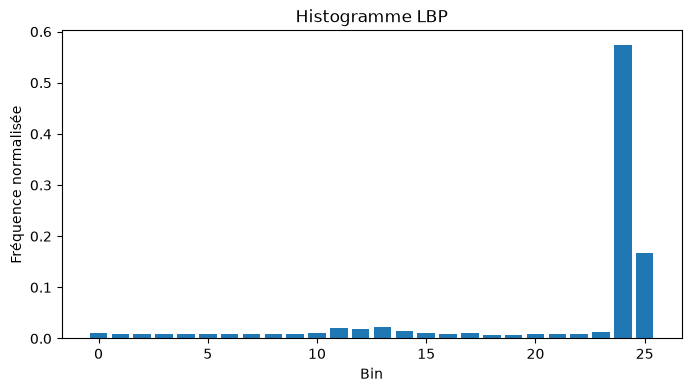

In [12]:
import matplotlib.pyplot as plt

lbp_transformer = LBPFeatures(
    image_size=(128, 128),
    radius=3,
    n_points=24
)

histogram = lbp_transformer.transform([X_train[0]])[0]

plt.figure(figsize=(8, 4))
plt.bar(range(len(histogram)), histogram)
plt.title("Histogramme LBP")
plt.xlabel("Bin")
plt.ylabel("Fréquence normalisée")
plt.show()
